# 3.1 Creating a neural network using the Sequential API

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9212 - loss: 0.2673 - val_accuracy: 0.9607 - val_loss: 0.1347
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9663 - loss: 0.1132 - val_accuracy: 0.9658 - val_loss: 0.1156
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9762 - loss: 0.0774 - val_accuracy: 0.9710 - val_loss: 0.0977
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9811 - loss: 0.0591 - val_accuracy: 0.9737 - val_loss: 0.0933
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9859 - loss: 0.0446 - val_accuracy: 0.9755 - val_loss: 0.0903
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9881 - loss: 0.0359 - val_accuracy: 0.9753 - val_loss: 0.0953
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.9743 - val_loss: 0.0963
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9910 - loss: 0.0259 - 

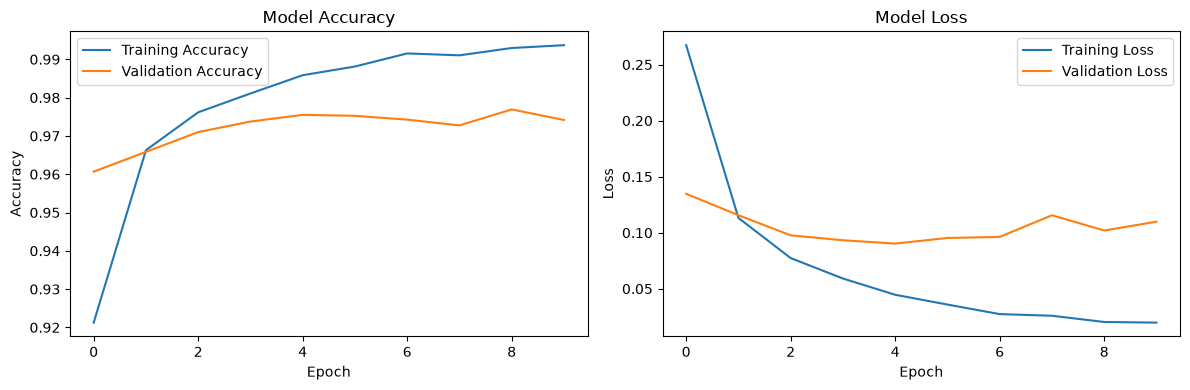

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


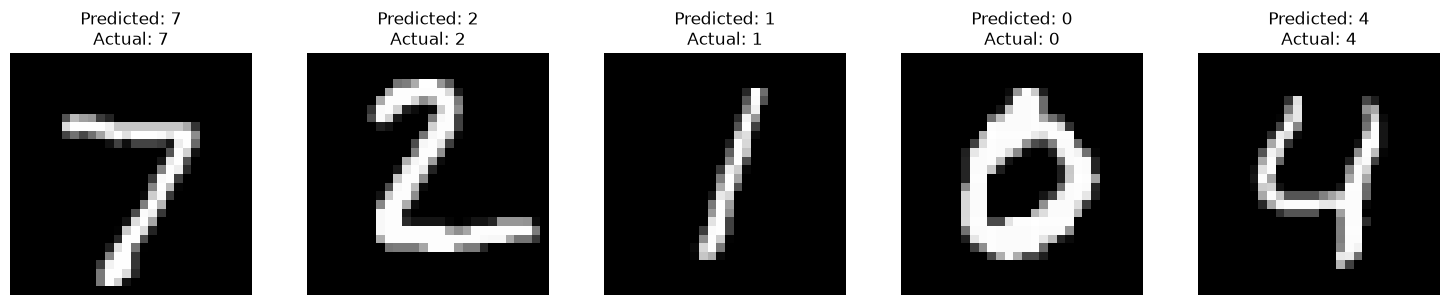

In [5]:
import os

# hide INFO/WARNING/ERROR від C++
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Disable oneDNN messages
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0 # Normalize pixel values to [0, 1]
# Define a simple feedforward neural network using the Sequential API
model = Sequential(
    [
        # Input layer specifying the shape of the input images
        Input(shape=(28, 28)),
        # Flatten 28×28 images to a 1D vector of 784 elements
        Flatten(),
        # Hidden layer with 128 units and ReLU activation
        Dense(128, activation="relu"),
        # Second hidden layer with 64 units and ReLU activation
        Dense(64, activation="relu"),
        # Output layer with 10 units for classification (0-9 digits)
        Dense(10, activation="softmax"),
    ]
)
# Compile the model
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32,
verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Make predictions on a few test images
predictions = model.predict(X_test[:5])
predicted_labels = tf.argmax(predictions, axis=1)

# Display the images and predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    ax.set_title(f"Predicted: {predicted_labels[i]}\nActual: {y_test[i]}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()

# 3.2 Creating a neural network using the Functional API

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.4403 - val_accuracy: 0.9540 - val_loss: 0.1573
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9457 - loss: 0.1825 - val_accuracy: 0.9663 - val_loss: 0.1139
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9579 - loss: 0.1379 - val_accuracy: 0.9684 - val_loss: 0.1052
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1104 - val_accuracy: 0.9737 - val_loss: 0.0891
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0947 - val_accuracy: 0.9743 - val_loss: 0.0885
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9748 - loss: 0.0829 - val_accuracy: 0.9779 - val_loss: 0.0774
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9764 - loss: 0.0761 - val_accuracy: 0.9765 - val_loss: 0.0800
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0658 - val_accuracy: 0.

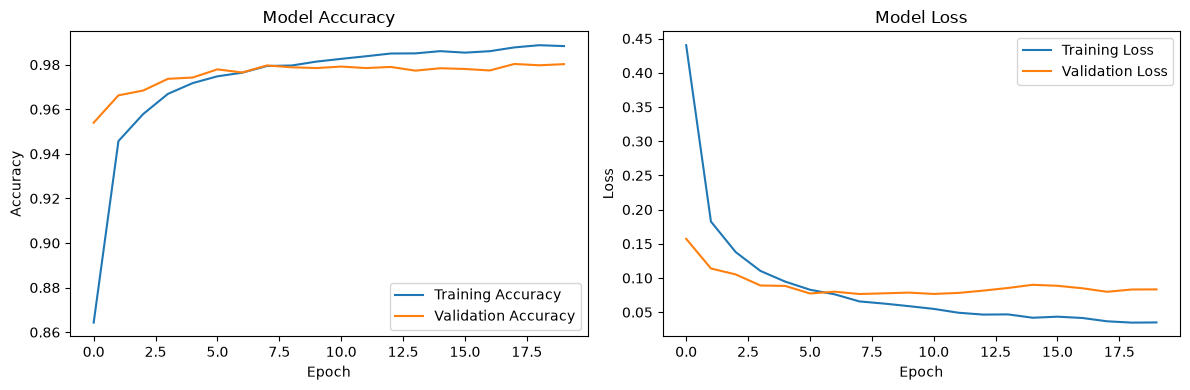

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


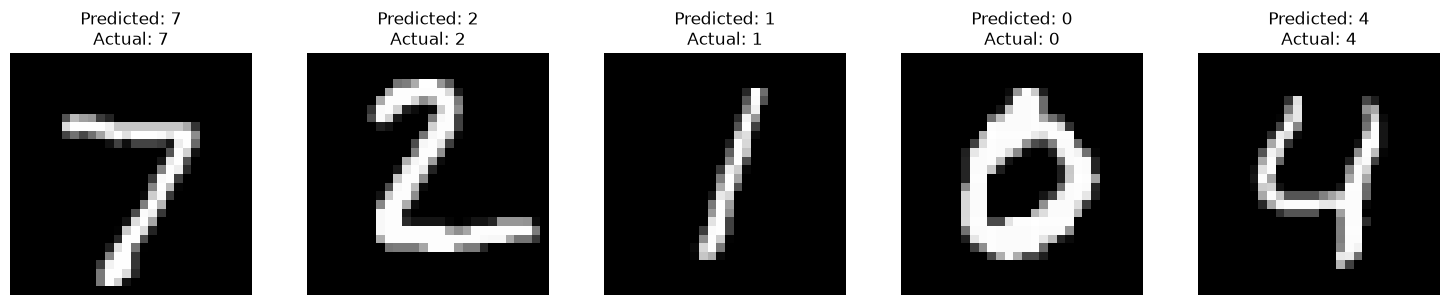

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define the input layer
inputs = Input(shape=(28, 28))
# Add a Flatten layer and Dense layers with Dropout
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
# Define the output layer
outputs = Dense(10, activation="softmax")(x)

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train, epochs=20, batch_size=128, validation_split=0.2, verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Make predictions on a few test images
predictions = model.predict(X_test[:5])
predicted_labels = tf.argmax(predictions, axis=1)

# Display the images and predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Predicted: {predicted_labels[i]}\nActual: {tf.argmax(y_test[i])}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()


# 3.3 Model compilation and training

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2422 - sparse_categorical_accuracy: 0.9294 - val_loss: 0.1284 - val_sparse_categorical_accuracy: 0.9606
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1029 - sparse_categorical_accuracy: 0.9678 - val_loss: 0.1020 - val_sparse_categorical_accuracy: 0.9683
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0706 - sparse_categorical_accuracy: 0.9778 - val_loss: 0.0879 - val_sparse_categorical_accuracy: 0.9742
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0513 - sparse_categorical_accuracy: 0.9839 - val_loss: 0.0854 - val_sparse_categorical_accuracy: 0.9760
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0435 - sparse_categorical_accuracy: 0.9858 - val_loss: 0.0876 - val_sparse_categorical_accuracy: 0.9751
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0349 - sparse_categorical_accuracy: 0.9888 - val_loss: 0.0862 - val_sparse_categorical_accuracy:

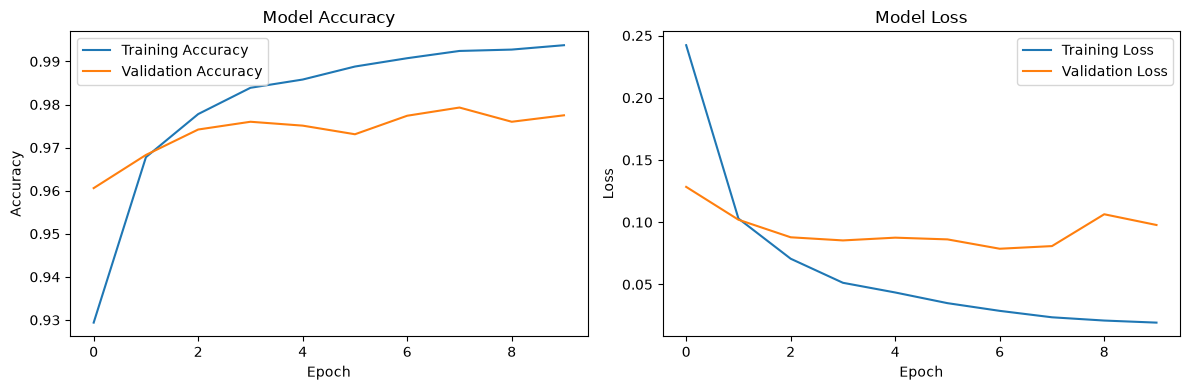

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Define the model
model = Sequential(
    [
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)
# Compile the model with Adam optimizer and sparse categorical crossentropy loss
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=[SparseCategoricalAccuracy()],
)
# Display model summary
model.summary()
# Train the model on training data
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
)
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["sparse_categorical_accuracy"], label="Training Accuracy")
plt.plot(
    history.history["val_sparse_categorical_accuracy"], label="Validation Accuracy"
)
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 3.4 Model evaluation

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2326 - sparse_categorical_accuracy: 0.9318 - val_loss: 0.1279 - val_sparse_categorical_accuracy: 0.9604
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0980 - sparse_categorical_accuracy: 0.9697 - val_loss: 0.0926 - val_sparse_categorical_accuracy: 0.9702
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0709 - sparse_categorical_accuracy: 0.9781 - val_loss: 0.0804 - val_sparse_categorical_accuracy: 0.9755
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0538 - sparse_categorical_accuracy: 0.9826 - val_loss: 0.0810 - val_sparse_categorical_accuracy: 0.9756
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0418 - sparse_categorical_accuracy: 0.9869 - val_loss: 0.0844 - val_sparse_categorical_accuracy: 0.9754
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0333 - sparse_categorical_accuracy: 0.9890 - val_loss: 0.0940 - val_sparse_categorical_accuracy:

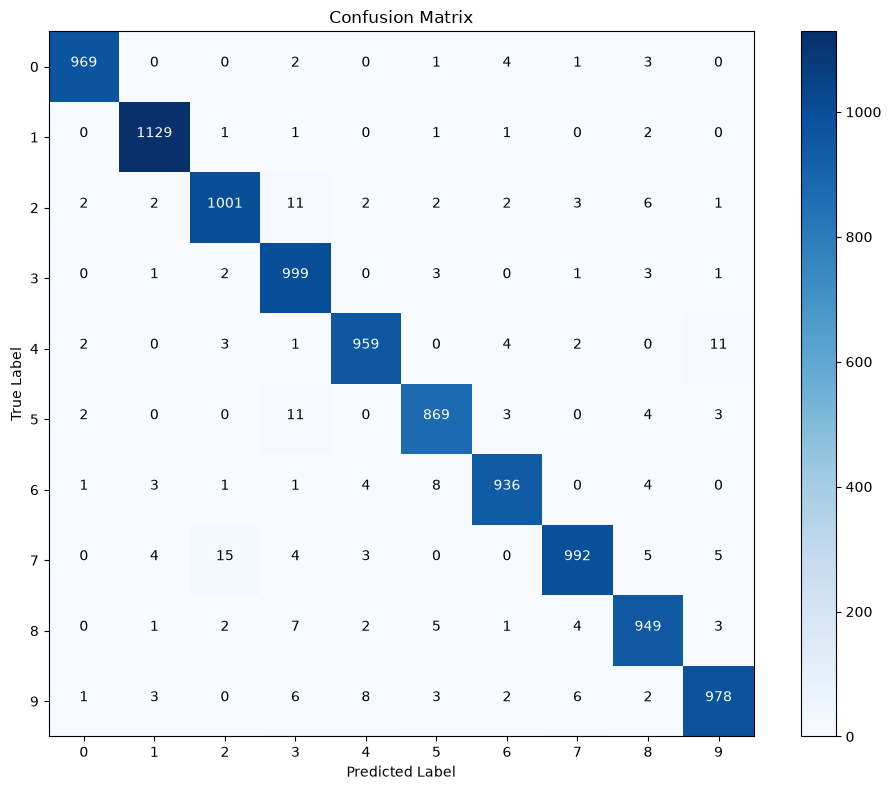

<Figure size 640x480 with 0 Axes>

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



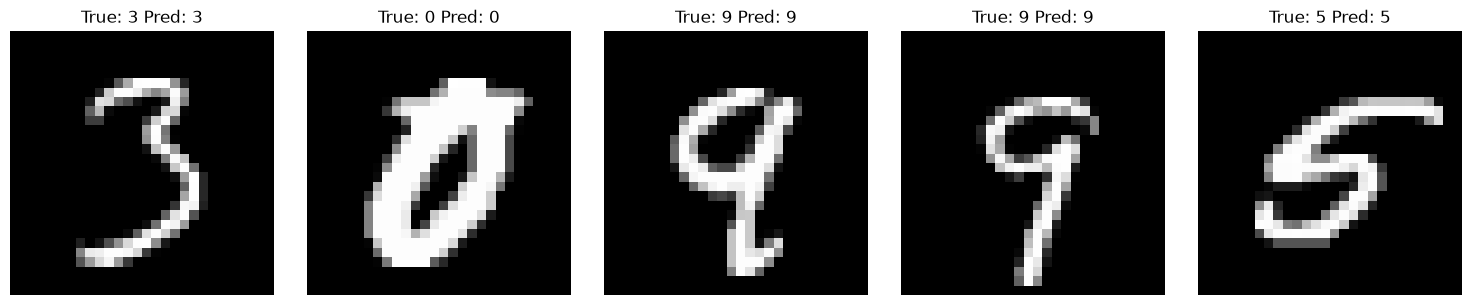

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.datasets import mnist

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Define the model
model = Sequential(
    [
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)
# Compile the model with Adam optimizer and sparse categorical crossentropy loss
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=[SparseCategoricalAccuracy()],
)
# Display model summary
model.summary()
# Train the model on training data
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
)

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.asarray(y_test).reshape(-1)
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations to the confusion matrix
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()
# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))
# Visualize some predictions
n_samples = 5
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)
plt.figure(figsize=(15, 3))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[idx]} Pred: {y_pred_classes[idx]}")
    plt.axis('off')
    
plt.tight_layout()
plt.show()

# 3.5 Creating a multi-output model using the Functional API

I0000 00:00:1791287969.045865   60480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791287969.046414   60480 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791287969.085153   60480 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791287970.066587   60480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12544)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  1,605,760 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_output     │ (None, 10)        │        650 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_output        │ (None, 3)         │        195 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,634,253 (6.23 MB)

 Trainable params: 1,634,253 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - category_output_accuracy: 0.1015 - category_output_loss: 2.3057 - color_output_accuracy: 0.3433 - color_output_loss: 1.0995 - loss: 2.8554 - val_category_output_accuracy: 0.1260 - val_category_output_loss: 2.3009 - val_color_output_accuracy: 0.3110 - val_color_output_loss: 1.0999 - val_loss: 2.8506
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - category_output_accuracy: 0.1115 - category_output_loss: 2.3018 - color_output_accuracy: 0.3390 - color_output_loss: 1.0989 - loss: 2.8513 - val_category_output_accuracy: 0.1260 - val_category_output_loss: 2.2999 - val_color_output_accuracy: 0.3110 - val_color_output_loss: 1.0994 - val_loss: 2.8494
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - category_output_accuracy: 0.1115 - category_output_loss: 2.3022 - color_output_accuracy: 0.3438 - color_output_loss: 1.0989 - loss: 2.8516 - val_category_output_accuracy: 0.1260 - val_category_output_loss: 2.2998 - val_color_output_acc

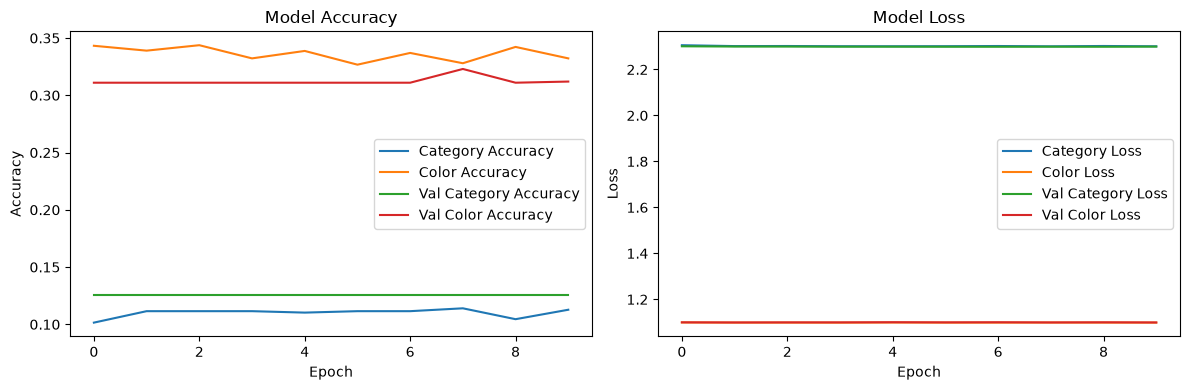

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted category: 8
Predicted color: 0


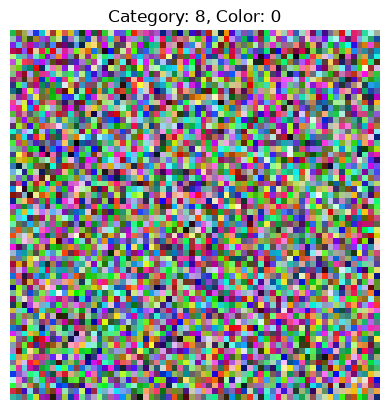

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


# Generate synthetic data
def generate_data(num_samples=1000):
    images = np.random.rand(num_samples, 64, 64, 3)
    categories = np.random.randint(0, 10, num_samples)
    colors = np.random.randint(0, 3, num_samples)
    return images, categories, colors


# Prepare data
X, y_category, y_color = generate_data(5000)
y_category = to_categorical(y_category, 10)
y_color = to_categorical(y_color, 3)

# Split data
(
    X_train,
    X_test,
    y_category_train,
    y_category_test,
    y_color_train,
    y_color_test,
) = train_test_split(X, y_category, y_color, test_size=0.2, random_state=42)

# Define the input layer
input_layer = Input(shape=(64, 64, 3))

# Convolutional layers
x = Conv2D(32, (3, 3), activation="relu")(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Flatten the output and add shared dense layers
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)

# Define the outputs
category_output = Dense(10, activation="softmax", name="category_output")(x)
color_output = Dense(3, activation="softmax", name="color_output")(x)

# Create and compile the multi-output model
model = Model(inputs=input_layer, outputs=[category_output, color_output])
model.compile(
    optimizer="adam",
    loss={
        "category_output": "categorical_crossentropy",
        "color_output": "categorical_crossentropy",
    },
    loss_weights={"category_output": 1.0, "color_output": 0.5},
    metrics={
        "category_output": ["accuracy"],
        "color_output": ["accuracy"],
    },
)
model.summary()

# Train the model
history = model.fit(
    X_train,
    {
        "category_output": y_category_train,
        "color_output": y_color_train,
    },
    validation_data=(
        X_test,
        {
            "category_output": y_category_test,
            "color_output": y_color_test,
        },
    ),
    epochs=10,
    batch_size=32,
)

# Evaluate the model
results = model.evaluate(
    X_test,
    {
        "category_output": y_category_test,
        "color_output": y_color_test,
    },
    return_dict=True,
)
print(f"Test category accuracy: {results['category_output_accuracy']:.4f}")
print(f"Test color accuracy: {results['color_output_accuracy']:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["category_output_accuracy"], label="Category Accuracy")
plt.plot(history.history["color_output_accuracy"], label="Color Accuracy")
plt.plot(
    history.history["val_category_output_accuracy"],
    label="Val Category Accuracy",
)
plt.plot(
    history.history["val_color_output_accuracy"],
    label="Val Color Accuracy",
)
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["category_output_loss"], label="Category Loss")
plt.plot(history.history["color_output_loss"], label="Color Loss")
plt.plot(
    history.history["val_category_output_loss"],
    label="Val Category Loss",
)
plt.plot(
    history.history["val_color_output_loss"],
    label="Val Color Loss",
)
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Make predictions
sample_image = X_test[0:1]
predictions = model.predict(sample_image)
predicted_category = np.argmax(predictions[0])
predicted_color = np.argmax(predictions[1])
print(f"Predicted category: {predicted_category}")
print(f"Predicted color: {predicted_color}")

# Display the sample image
plt.imshow(sample_image[0])
plt.title(f"Category: {predicted_category}, Color: {predicted_color}")
plt.axis("off")
plt.show()